#  Cats vs Dogs 


## 1) Imports & Paths

In [3]:

import os, glob, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# 🔧 CHANGE THIS to your local path that contains 'cats/' and 'dogs/'
DATA_DIR = "PetImages"

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
VAL_FRAC   = 0.20
SEED       = 123

os.makedirs("checkpoints", exist_ok=True)


TensorFlow: 2.17.0
GPU available: []


## 2) Safe Loader (`ignore_errors`) + Cardinality Helper

In [4]:

def ds_info(ds, name):
    card = ds.cardinality().numpy()  # -1 unknown, -2 infinite
    text = "unknown" if card < 0 else str(int(card))
    print(f"{name} batches (after batching): {text}")

# Build file list
cats = sorted(glob.glob(os.path.join(DATA_DIR, "cats", "*")))
dogs = sorted(glob.glob(os.path.join(DATA_DIR, "dogs", "*")))

if len(cats) == 0 or len(dogs) == 0:
    raise FileNotFoundError("Could not find images. Make sure DATA_DIR has 'cats/' and 'dogs/' subfolders.")

paths  = np.array(cats + dogs)
labels = np.array([0]*len(cats) + [1]*len(dogs), dtype=np.int32)

# Shuffle + split
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(paths))
paths, labels = paths[idx], labels[idx]
val_n = int(len(paths) * VAL_FRAC)

val_paths, val_labels = paths[:val_n], labels[:val_n]
tr_paths,  tr_labels  = paths[val_n:], labels[val_n:]

def _decode(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)  # raises if corrupt
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32)

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(_decode, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.ignore_errors()  # TF 2.17 way
    if training:
        def aug(img, y):
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, 0.05)
            return img, y
        ds = ds.map(aug, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(tr_paths,  tr_labels,  training=True)
val_ds   = make_ds(val_paths, val_labels, training=False)

ds_info(train_ds, "Train")
ds_info(val_ds,   "Val")


Train batches (after batching): unknown
Val batches (after batching): unknown


## 3) ANN (Baseline)

In [5]:

ann_cd = Sequential([
    Flatten(input_shape=IMG_SIZE + (3,)),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])
ann_cd.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann_cd.summary()

callbacks_ann = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('checkpoints/ann_catdog.keras', monitor='val_loss', save_best_only=True)
]

history_ann = ann_cd.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks_ann, verbose=1)


C:\Users\janna\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,583,425 (48.00 MB)

 Trainable params: 12,583,425 (48.00 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
     26/Unknown 9s 253ms/step - accuracy: 0.5112 - loss: 18.7038

c:\Program Files\Python312\Lib\contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 440ms/step - accuracy: 0.5114 - loss: 18.5017 - val_accuracy: 0.5075 - val_loss: 1.2830
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 340ms/step - accuracy: 0.5306 - loss: 2.3358 - val_accuracy: 0.4627 - val_loss: 0.7034
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 324ms/step - accuracy: 0.5033 - loss: 0.7167 - val_accuracy: 0.4826 - val_loss: 0.6964
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 332ms/step - accuracy: 0.5195 - loss: 0.6915 - val_accuracy: 0.5373 - val_loss: 0.6931
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.5278 - loss: 0.6908 - val_accuracy: 0.5075 - val_loss: 0.6934
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 314ms/step - accuracy: 0.5161 - loss: 0.6883 - val_accuracy: 0.5373 - val_loss: 0.6931
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 192ms/step - accuracy: 0.4902 - loss: 0.6932 - val_accuracy: 0.5373 - val_loss: 0.6935
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 316ms/step - accuracy: 0.5112 - loss: 0.6932 - val_accuracy: 0.5373 - va

## 4) CNN (Improved Accuracy)

In [6]:

cnn_cd = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=IMG_SIZE + (3,)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])
cnn_cd.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_cd.summary()

callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('checkpoints/cnn_catdog.keras', monitor='val_loss', save_best_only=True)
]

history_cnn = cnn_cd.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks_cnn, verbose=1)


C:\Users\janna\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,289 (24.86 MB)

 Trainable params: 6,516,289 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 353ms/step - accuracy: 0.5338 - loss: 0.8316 - val_accuracy: 0.5373 - val_loss: 0.6916
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 350ms/step - accuracy: 0.4722 - loss: 0.6966 - val_accuracy: 0.5124 - val_loss: 0.6927
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 315ms/step - accuracy: 0.4785 - loss: 0.6933 - val_accuracy: 0.4627 - val_loss: 0.6928
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 349ms/step - accuracy: 0.5175 - loss: 0.6883 - val_accuracy: 0.5622 - val_loss: 0.6829
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 337ms/step - accuracy: 0.6009 - loss: 0.6760 - val_accuracy: 0.6318 - val_loss: 0.6719
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 342ms/step - accuracy: 0.6245 - loss: 0.6555 - val_accuracy: 0.6318 - val_loss: 0.6434
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 332ms/step - accuracy: 0.6392 - loss: 0.6216 - val_accuracy: 0.6368 - val_loss: 0.6517
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 371ms/step - accuracy: 0.6322 - loss: 0.6289 - val_accuracy: 

## 5) Curves

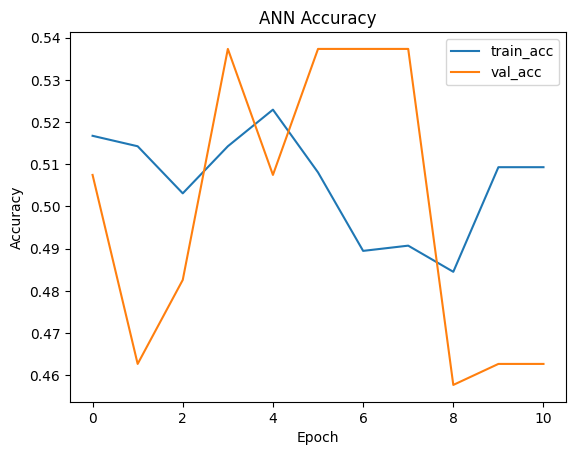

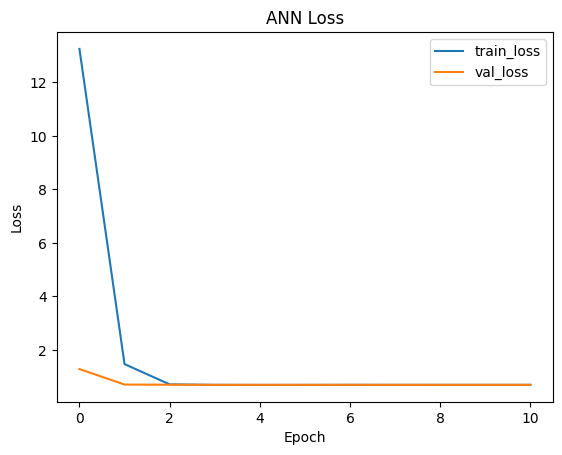

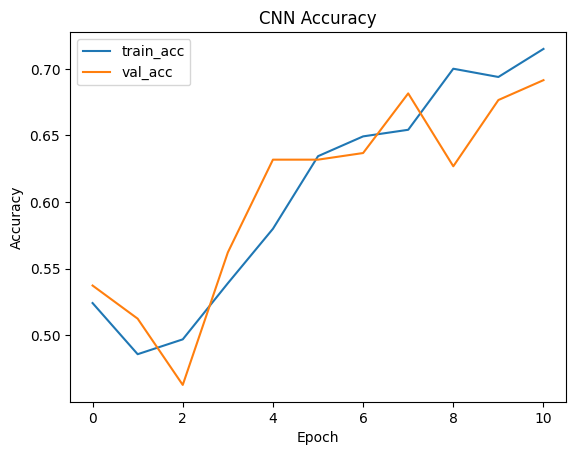

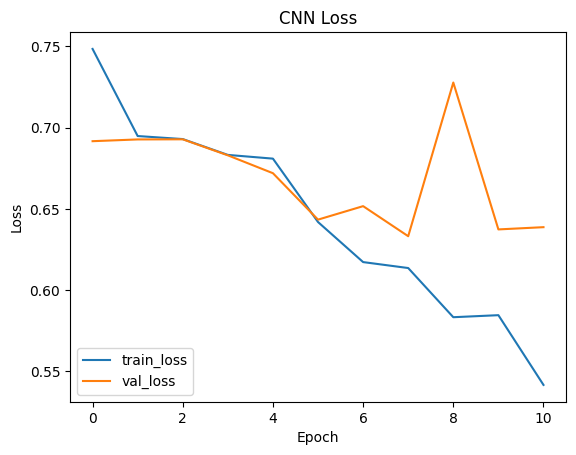

In [7]:

def plot_curves(history, title_prefix=""):
    plt.figure()
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title(f"{title_prefix} Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()

    plt.figure()
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f"{title_prefix} Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

plot_curves(history_ann, "ANN")
plot_curves(history_cnn, "CNN")


## 6) Evaluation

In [8]:

val_loss, val_acc = cnn_cd.evaluate(val_ds, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f} | Loss: {val_loss:.4f}")

y_true = np.concatenate([y for _, y in val_ds], axis=0)
y_pred_prob = cnn_cd.predict(val_ds, verbose=0).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Cat','Dog'], digits=4))


Validation Accuracy: 0.6816 | Loss: 0.6332

Confusion Matrix:
[[94 14]
 [50 43]]

Classification Report:
              precision    recall  f1-score   support

         Cat     0.6528    0.8704    0.7460       108
         Dog     0.7544    0.4624    0.5733        93

    accuracy                         0.6816       201
   macro avg     0.7036    0.6664    0.6597       201
weighted avg     0.6998    0.6816    0.6661       201

